In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr

In [2]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

emulator_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-03-26-eval:samudra_llc:epoch1_oct2012_patchloc=i(2880,3600)-j(720,1440)/predictions_4d.zarr'
emulator_patch_full = xr.open_dataset(emulator_path, consolidated=True)
#emulator_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [3]:
#9216,9960

## Theta

In [4]:
extent = 3
llc_patch = llc_patch_full.isel(time=slice(9216, 9216 + extent))
emulator_patch = emulator_patch_full.isel(time=slice(0, extent))#(9216, 9216 + extent))#(0, extent))

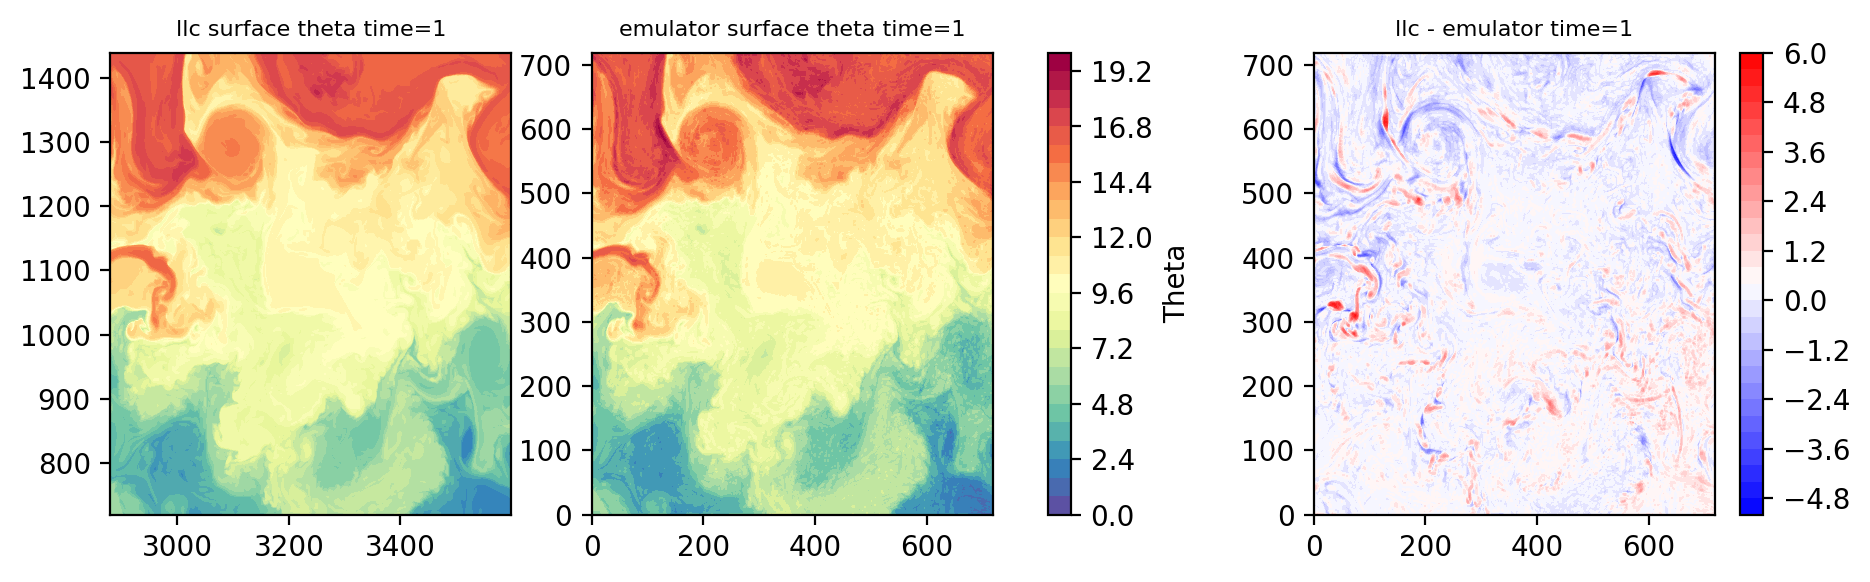

In [5]:
llc_vis = llc_patch.isel(time=1,k=0).Theta
emulator_vis = emulator_patch.isel(time=1,k=0).Theta

# Get shared vmin/vmax for llc and emulator
vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
ax1.set_title('llc surface theta time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="Spectral_r", vmin=vmin, vmax=vmax, levels = 30)
ax2.set_title('emulator surface theta time=1', fontsize=8)

# Single colorbar for ax1 and ax2
cbar = plt.colorbar(cf2, ax=[ax1, ax2])
cbar.set_label('Theta')

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="bwr", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

#plt.tight_layout()
plt.show()

In [6]:
Theta_hist_llc = llc_patch.Theta.stack(vals=['time','i','j']).values
Theta_hist_emulator = emulator_patch.Theta.stack(vals=['time','lon','lat']).values

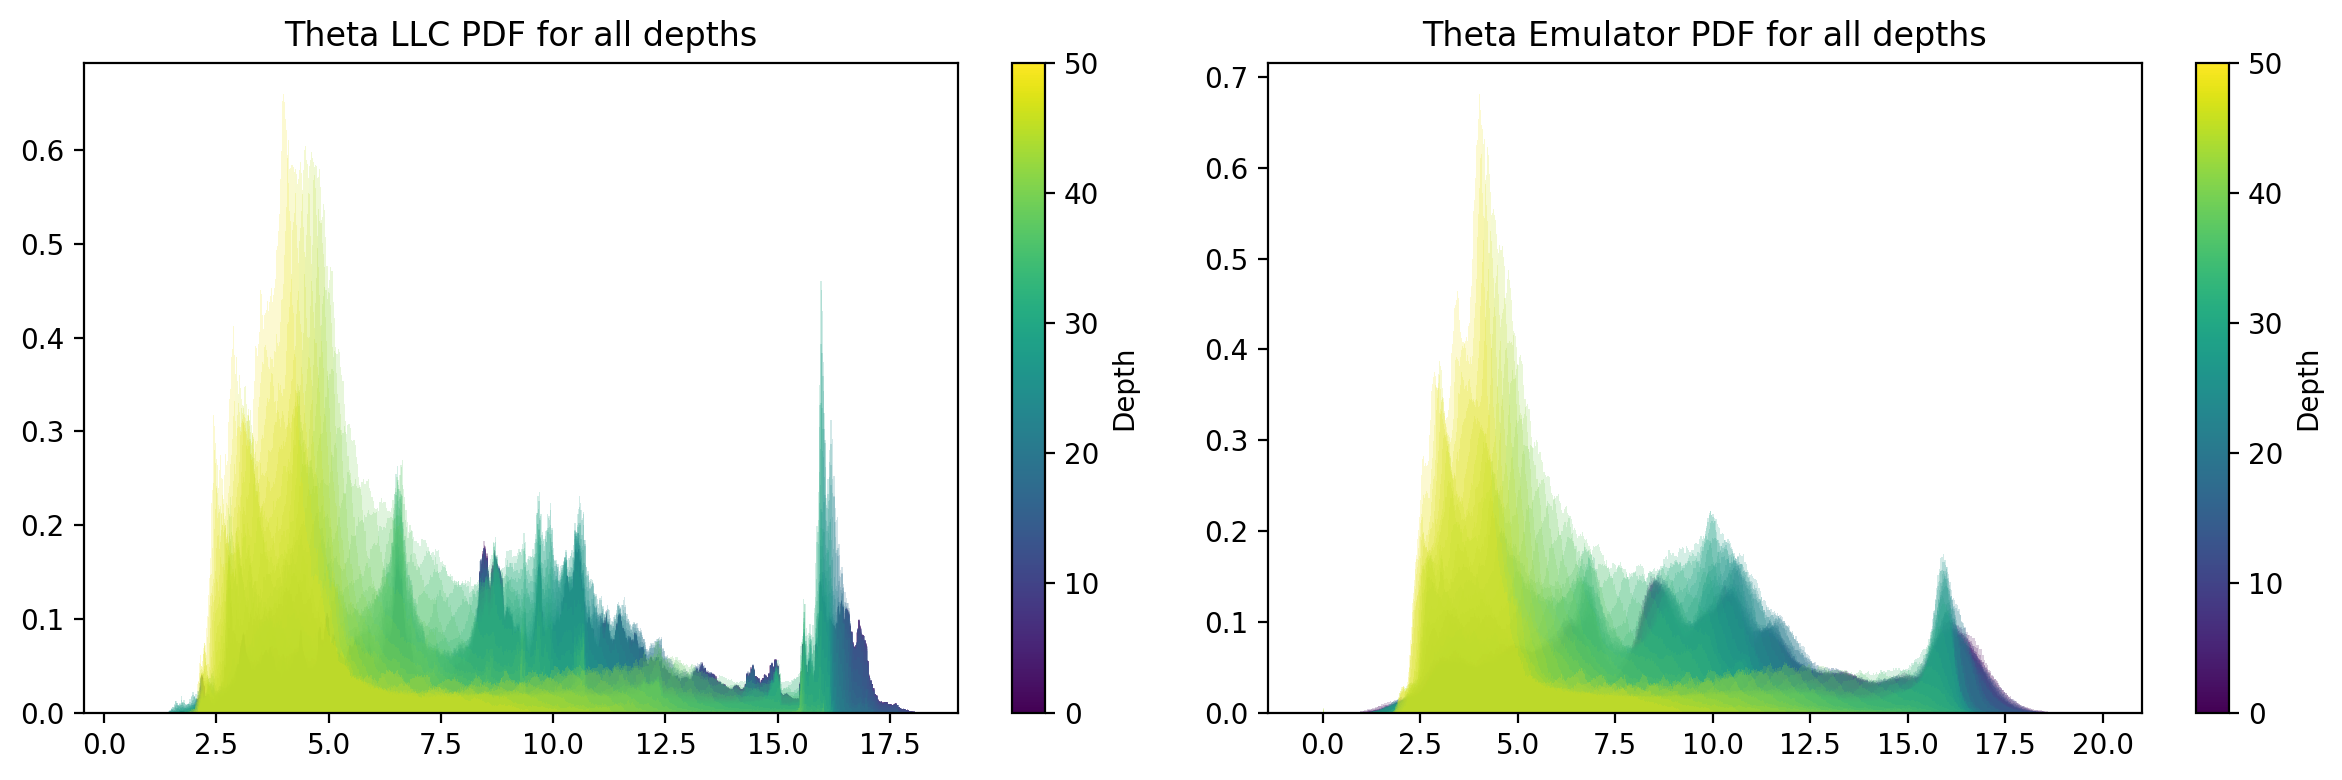

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

cm = [plt.cm.viridis(i/len(Theta_hist_llc)) for i in range(len(Theta_hist_llc))]
for k in range(0,len(Theta_hist_llc)):
    ax1.hist(Theta_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Theta_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('Theta LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(Theta_hist_emulator)) for i in range(len(Theta_hist_emulator))]
for k in range(0,len(Theta_hist_emulator)):
    ax2.hist(Theta_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Theta_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('Theta Emulator PDF for all depths')
plt.tight_layout()
plt.savefig('figs/PDFs/Theta_PDFs_combined_depths.png')
plt.show()

In [ ]:
n_depths = len(Theta_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(Theta_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(Theta_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.legend(fontsize=7)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.savefig('figs/PDFs/Theta_PDFs_distinct_depths.png')
#plt.show()
plt.close()

## Salt

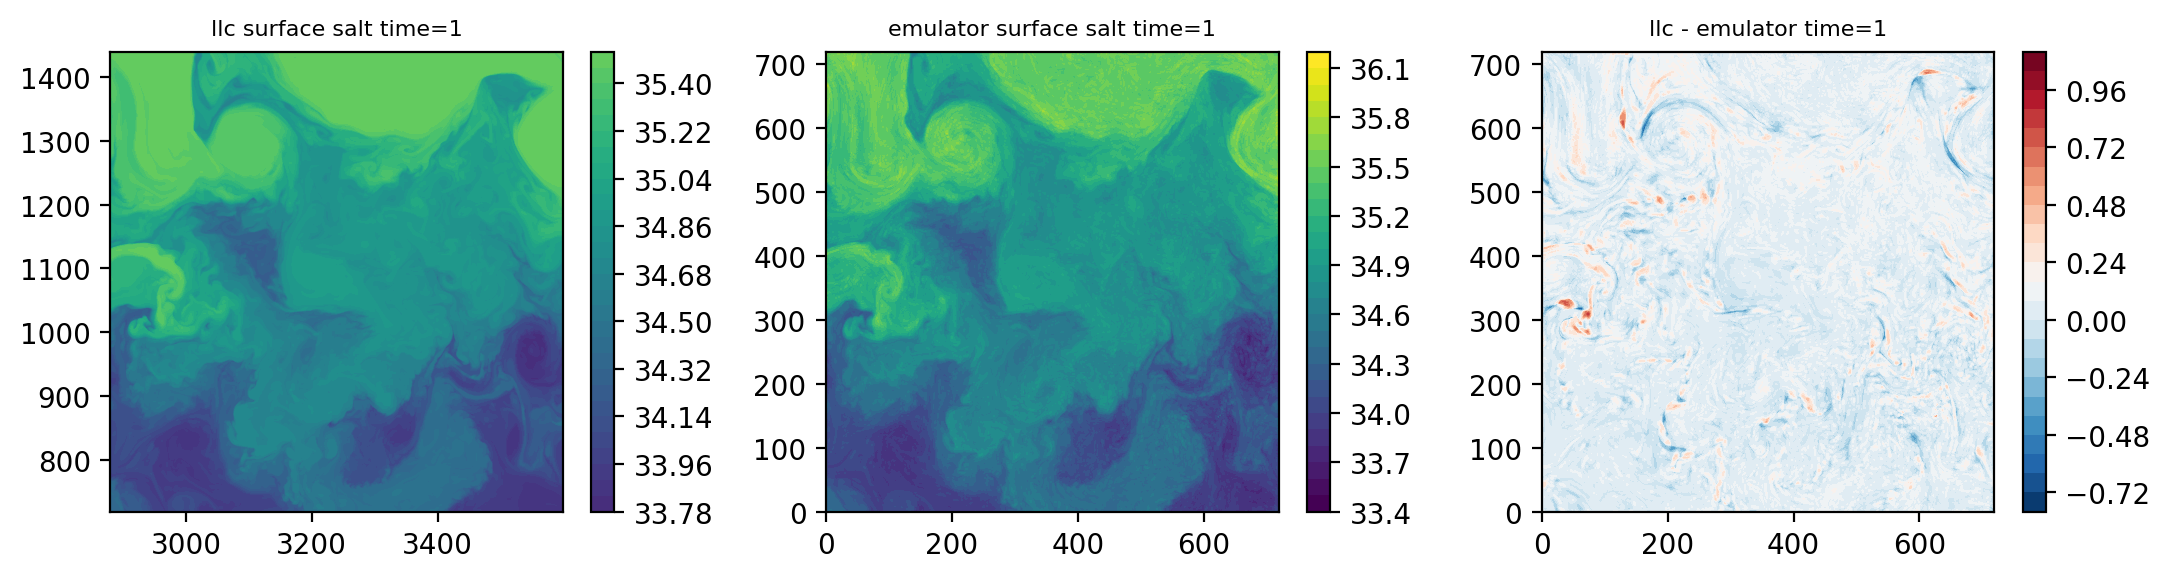

In [9]:
llc_vis = llc_patch.isel(time=1,k=0).Salt
emulator_vis = emulator_patch.isel(time=1,k=0).Salt

# Get shared vmin/vmax for llc and emulator
vmin = np.min([llc_vis.values.min(), emulator_vis.values.min()])
vmax = np.max([llc_vis.values.max(), emulator_vis.values.max()])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="viridis", vmin=vmin, vmax=vmax, levels = 30)
ax1.set_title('llc surface salt time=1', fontsize=8)
plt.colorbar(cf1, ax=ax1)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="viridis", vmin=vmin, vmax=vmax, levels = 30)
ax2.set_title('emulator surface salt time=1', fontsize=8)
plt.colorbar(cf2, ax=ax2)

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="RdBu_r", levels = 30)
ax3.set_title('llc - emulator time=1', fontsize=8)
plt.colorbar(cf3, ax=ax3)

plt.tight_layout()
plt.show()
plt.close()

In [10]:
Salt_hist_llc = llc_patch.Salt.stack(vals=['time','i','j']).values
Salt_hist_emulator = emulator_patch.Salt.stack(vals=['time','lon','lat']).values

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

cm = [plt.cm.viridis(i/len(Salt_hist_llc)) for i in range(len(Salt_hist_llc))]
for k in range(0,len(Salt_hist_llc)):
    ax1.hist(Salt_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Salt_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('Salt LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(Salt_hist_emulator)) for i in range(len(Salt_hist_emulator))]
for k in range(0,len(Salt_hist_emulator)):
    ax2.hist(Salt_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Salt_hist_emulator)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('Salt Emulator PDF for all depths')
plt.tight_layout()
plt.savefig('figs/PDFs/Salt_PDFs_combined_depths.png')
#plt.show()
plt.close()

In [12]:
n_depths = len(Salt_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(Salt_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(Salt_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.legend(fontsize=7)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.savefig('figs/PDFs/Salt_PDFs_distinct_depths.png')
#plt.show()
plt.close()

## U, V

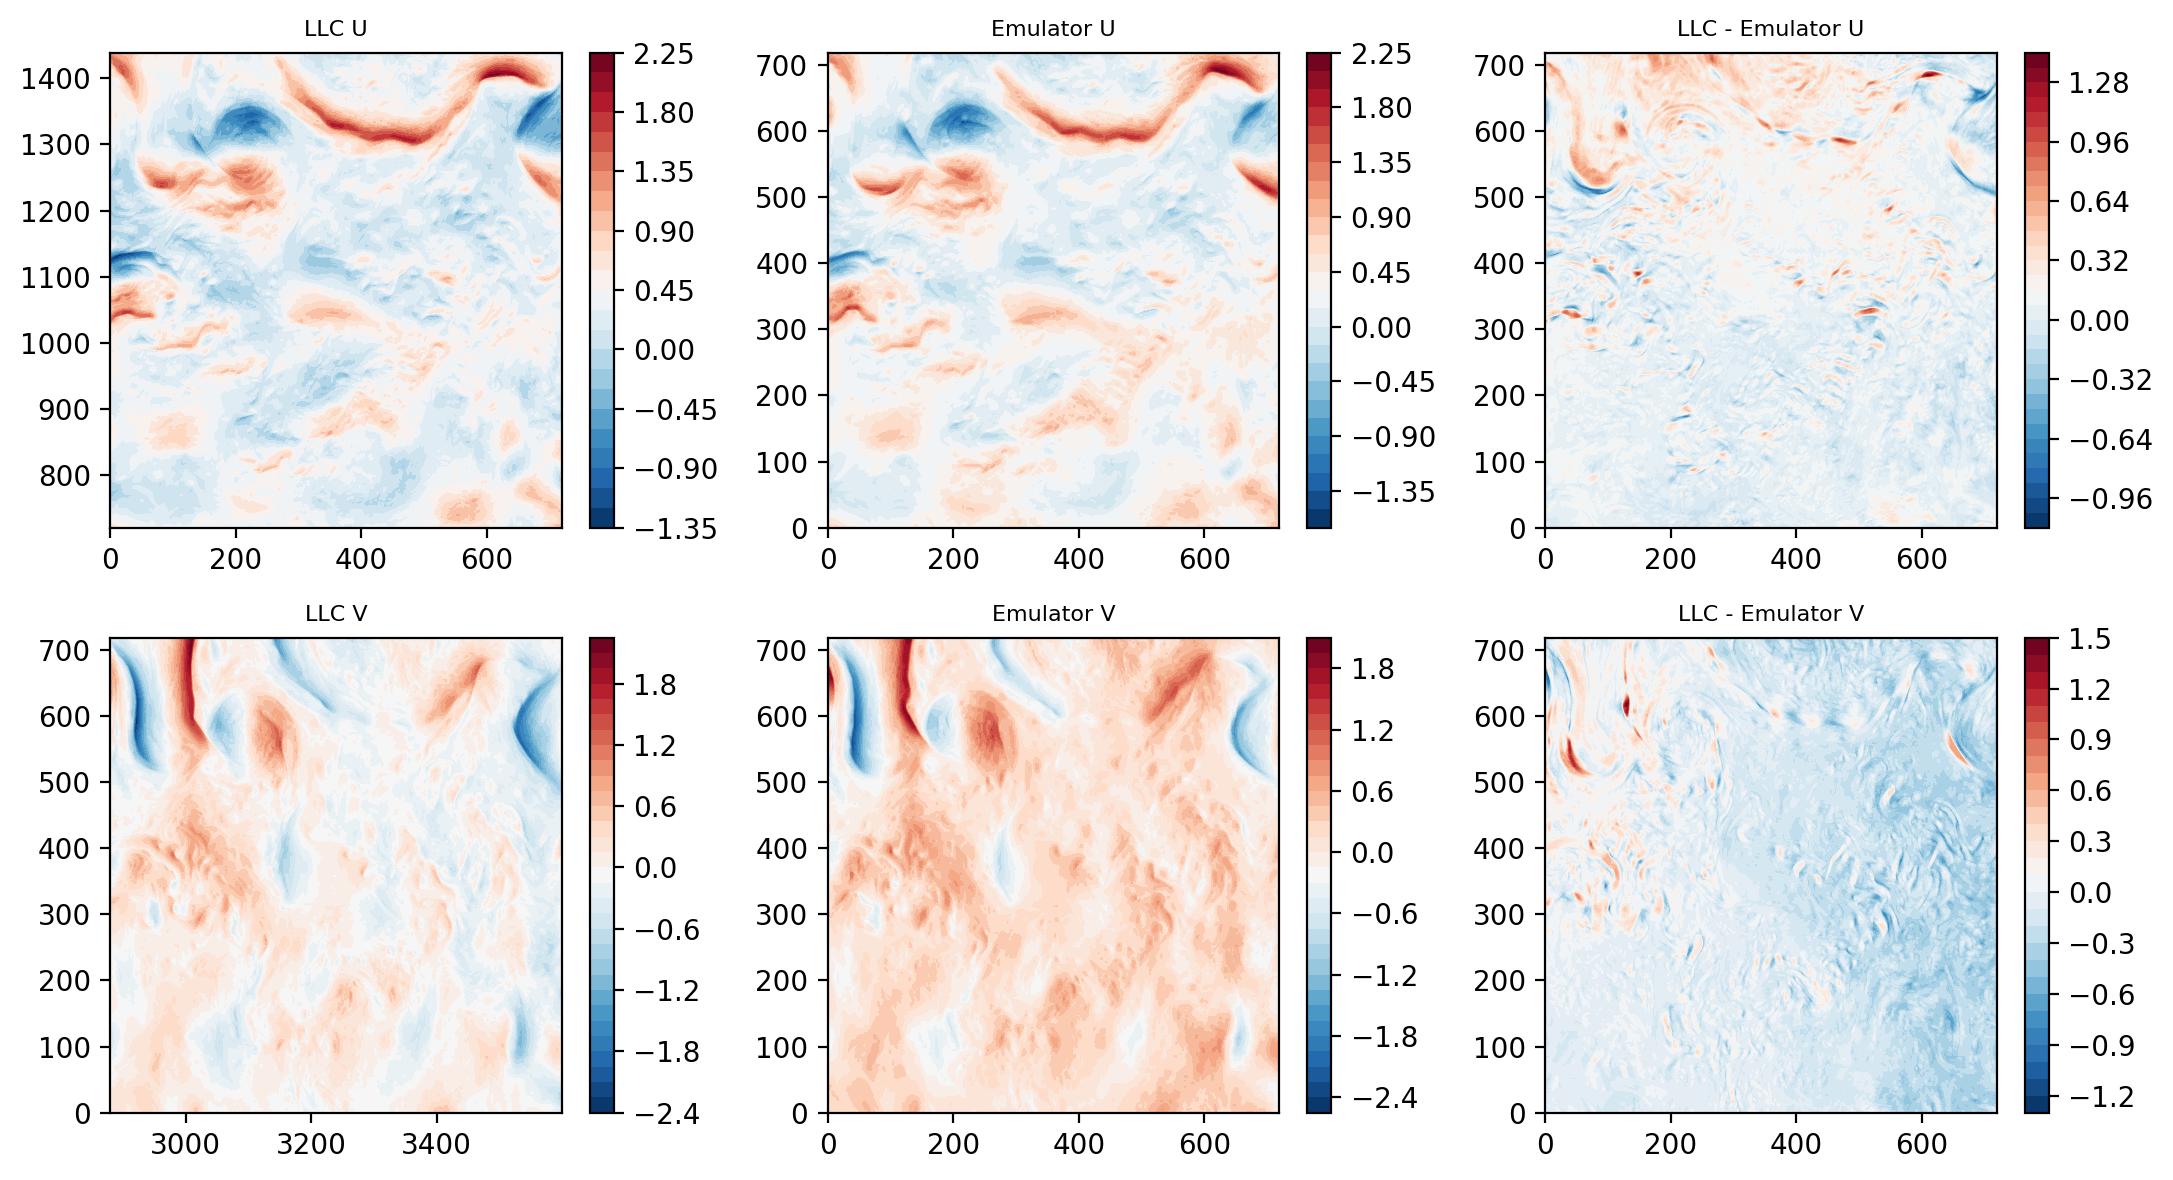

In [13]:
llc_vis_U = llc_patch.isel(time=1,k=0).U
emulator_vis_U = emulator_patch.isel(time=1,k=0).U
llc_vis_V = llc_patch.isel(time=1,k=0).V
emulator_vis_V = emulator_patch.isel(time=1,k=0).V

fig, axes = plt.subplots(2, 3, figsize=(11, 6), dpi=200)

# Row 1: U
cf1 = axes[0,0].contourf(llc_vis_U.coords.get('i', np.arange(llc_vis_U.shape[-1])), 
    llc_vis_U.coords.get('j', np.arange(llc_vis_U.shape[-2])), llc_vis_U, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf1, ax=axes[0,0])
axes[0,0].set_title('LLC U', fontsize=8)

cf2 = axes[0,1].contourf(emulator_vis_U.coords.get('i', np.arange(emulator_vis_U.shape[-1])), 
    emulator_vis_U.coords.get('j', np.arange(emulator_vis_U.shape[-2])), emulator_vis_U, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf2, ax=axes[0,1])
axes[0,1].set_title('Emulator U', fontsize=8)

cf3 = axes[0,2].contourf(emulator_vis_U.coords.get('i', np.arange(emulator_vis_U.shape[-1])), 
    emulator_vis_U.coords.get('j', np.arange(emulator_vis_U.shape[-2])), llc_vis_U.values - emulator_vis_U.values, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf3, ax=axes[0,2])
axes[0,2].set_title('LLC - Emulator U', fontsize=8)

# Row 2: V
cf4 = axes[1,0].contourf(llc_vis_V.coords.get('i', np.arange(llc_vis_V.shape[-1])), 
    llc_vis_V.coords.get('j', np.arange(llc_vis_V.shape[-2])), llc_vis_V, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf4, ax=axes[1,0])
axes[1,0].set_title('LLC V', fontsize=8)

cf5 = axes[1,1].contourf(emulator_vis_V.coords.get('i', np.arange(emulator_vis_V.shape[-1])), 
    emulator_vis_V.coords.get('j', np.arange(emulator_vis_V.shape[-2])), emulator_vis_V, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf5, ax=axes[1,1])
axes[1,1].set_title('Emulator V', fontsize=8)

cf6 = axes[1,2].contourf(emulator_vis_V.coords.get('i', np.arange(emulator_vis_V.shape[-1])), 
    emulator_vis_V.coords.get('j', np.arange(emulator_vis_V.shape[-2])), llc_vis_V.values - emulator_vis_V.values, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf6, ax=axes[1,2])
axes[1,2].set_title('LLC - Emulator V', fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
U_hist_llc = llc_patch.U.stack(vals=['time','i_g','j']).values
U_hist_emulator = emulator_patch.U.stack(vals=['time','lon','lat']).values

V_hist_llc = llc_patch.V.stack(vals=['time','i','j_g']).values
V_hist_emulator = emulator_patch.V.stack(vals=['time','lon','lat']).values

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=200)

# U LLC
cm = [plt.cm.viridis(i/len(U_hist_llc)) for i in range(len(U_hist_llc))]
for k in range(0, len(U_hist_llc)):
    axes[0,0].hist(U_hist_llc[k], bins=500, density=True, color=cm[k], alpha=0.2)
axes[0,0].set_yscale('log')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(U_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=axes[0,0])
axes[0,0].set_title('U LLC PDF for all depths')

# U Emulator
cm = [plt.cm.viridis(i/len(U_hist_emulator)) for i in range(len(U_hist_emulator))]
for k in range(0, len(U_hist_emulator)):
    axes[0,1].hist(U_hist_emulator[k], bins=500, density=True, color=cm[k], alpha=0.2)
axes[0,1].set_yscale('log')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(U_hist_emulator)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=axes[0,1])
axes[0,1].set_title('U Emulator PDF for all depths')

# V LLC
cm = [plt.cm.viridis(i/len(V_hist_llc)) for i in range(len(V_hist_llc))]
for k in range(0, len(V_hist_llc)):
    axes[1,0].hist(V_hist_llc[k], bins=500, density=True, color=cm[k], alpha=0.2)
axes[1,0].set_yscale('log')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(V_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=axes[1,0])
axes[1,0].set_title('V LLC PDF for all depths')

# V Emulator
cm = [plt.cm.viridis(i/len(V_hist_emulator)) for i in range(len(V_hist_emulator))]
for k in range(0, len(V_hist_emulator)):
    axes[1,1].hist(V_hist_emulator[k], bins=500, density=True, color=cm[k], alpha=0.2)
axes[1,1].set_yscale('log')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(V_hist_emulator)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=axes[1,1])
axes[1,1].set_title('V Emulator PDF for all depths')

plt.tight_layout()
plt.savefig('figs/PDFs/velocities_PDFs_combined_depths.png')
#plt.show()
plt.close()

In [16]:
n_depths = len(U_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(U_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(U_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_yscale('log')

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.savefig('figs/PDFs/U_PDFs_distinct_depths.png')
#plt.show()
plt.close()

/tmp/ipykernel_396233/480926132.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('figs/PDFs/U_PDFs_distinct_depths.png')


In [17]:
n_depths = len(V_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(V_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(V_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_yscale('log')

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.savefig('figs/PDFs/V_PDFs_distinct_depths.png')
#plt.show()
plt.close()